# Learning-Curve Model Comparison

This notebook compares the data efficiency and validation performance of the text-classification models developed in this project.

The analysis combines the learning-curve results of TF-IDF + Logistic Regression, DistilBERT German, mmBERT-small, mmBERT-base, GeLECTRA-large, and XLM-RoBERTa base.

Validation accuracy is compared across increasing training-set sizes to evaluate how strongly each model benefits from additional data, how efficiently it performs with limited training data, and which model achieves the strongest final performance.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.ticker import PercentFormatter

## Learning-Curve Comparison Table

Compare validation accuracy across all models at each training-set size to assess data efficiency and performance improvements as more training data becomes available.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.ticker import PercentFormatter

In [8]:
files = {
    "TF-IDF + Logistic Regression":
        "tfidf-logreg-learning-curve.csv",

    "DistilBERT German":
        "distilbert-german-learning-curve.csv",

    "mmBERT-small":
        "mmbert-small-learning-curve.csv",

    "mmBERT-base":
        "mmbert-base-learning-curve.csv",

    "GeLECTRA-large":
        "gelectra-large-learning-curve.csv",

    "XLM-RoBERTa base":
        "xlm-roberta-base-learning-curve.csv",
}


target_fractions = {
    "1%": 0.01,
    "5%": 0.05,
    "12%": 0.12,
    "17.5%": 0.175,
    "25%": 0.25,
    "50%": 0.50,
    "100%": 1.00,
}


rows = []

for model_name, file_path in files.items():
    df = pd.read_csv(file_path)

    for label, target in target_fractions.items():
        row = df.iloc[
            np.argmin(
                np.abs(
                    df["training_fraction"] - target
                )
            )
        ]

        rows.append(
            {
                "model": model_name,
                "training_data": label,
                "validation_accuracy":
                    row["validation_accuracy"],
            }
        )


comparison_data = pd.DataFrame(
    rows
)


comparison_table = (
    comparison_data
    .pivot(
        index="model",
        columns="training_data",
        values="validation_accuracy",
    )
    .reindex(
        columns=[
            "1%",
            "5%",
            "12%",
            "17.5%",
            "25%",
            "50%",
            "100%",
        ]
    )
)


comparison_table.columns.name = None
comparison_table.index.name = None


comparison_table.to_csv(
    "learning-curve-comparison-table.csv"
)


display(
    comparison_table.style
    .format("{:.2%}")
    .set_caption(
        "Validation accuracy by training-set size"
    )
)

,1%,5%,12%,17.5%,25%,50%,100%
DistilBERT German,46.42%,69.10%,75.05%,78.87%,82.35%,87.82%,90.50%
GeLECTRA-large,69.34%,83.34%,90.09%,93.74%,93.67%,93.98%,95.84%
TF-IDF + Logistic Regression,76.29%,84.21%,87.20%,88.16%,88.99%,90.33%,91.33%
XLM-RoBERTa base,51.72%,60.91%,78.49%,81.11%,84.62%,88.58%,91.60%
mmBERT-base,65.97%,87.20%,91.43%,93.43%,94.22%,95.11%,96.25%
mmBERT-small,37.54%,86.55%,90.95%,91.95%,92.57%,94.53%,94.84%


## Learning-Curve Comparison

Visualize validation accuracy across increasing training-set sizes to compare how the different models benefit from additional training data.

In [3]:
files = {
    "TF-IDF + Logistic Regression":
        "tfidf-logreg-learning-curve.csv",

    "DistilBERT German":
        "distilbert-german-learning-curve.csv",

    "mmBERT-small":
        "mmbert-small-learning-curve.csv",

    "mmBERT-base":
        "mmbert-base-learning-curve.csv",

    "GeLECTRA-large":
        "gelectra-large-learning-curve.csv",

    "XLM-RoBERTa base":
        "xlm-roberta-base-learning-curve.csv",
}


frames = []

for model_name, file_path in files.items():
    df = pd.read_csv(file_path)
    df["model"] = model_name
    frames.append(df)


learning_curves = pd.concat(
    frames,
    ignore_index=True,
)


fraction_labels = [
    "1%",
    "5%",
    "12%",
    "17.5%",
    "25%",
    "50%",
    "100%",
]

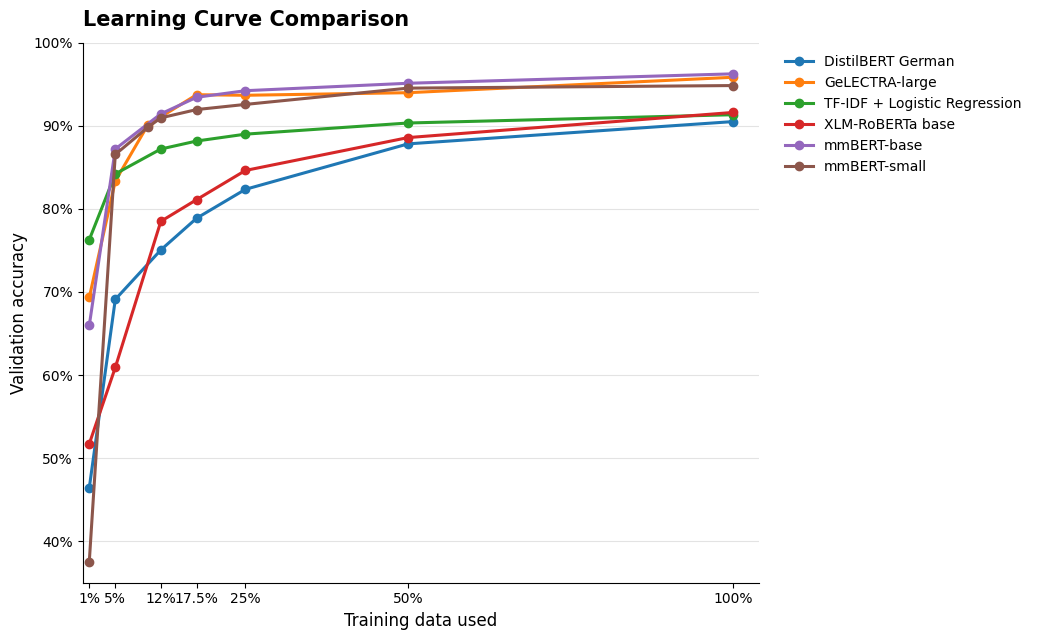

In [4]:
fig, ax = plt.subplots(
    figsize=(10.5, 6.5)
)

for model_name, model_df in learning_curves.groupby(
    "model"
):
    model_df = (
        model_df
        .sort_values("training_fraction")
    )

    ax.plot(
        model_df["training_fraction"] * 100,
        model_df["validation_accuracy"],
        marker="o",
        markersize=6,
        linewidth=2.2,
        label=model_name,
    )


ax.set_xticks(
    [1, 5, 12, 17.5, 25, 50, 100],
    fraction_labels,
)

ax.set_xlim(
    0,
    104,
)

ax.set_ylim(
    0.35,
    1.00,
)

ax.yaxis.set_major_formatter(
    PercentFormatter(1.0)
)

ax.set_xlabel(
    "Training data used",
    fontsize=12,
)

ax.set_ylabel(
    "Validation accuracy",
    fontsize=12,
)

ax.set_title(
    "Learning Curve Comparison",
    fontsize=15,
    fontweight="bold",
    loc="left",
    pad=12,
)

ax.grid(
    axis="y",
    alpha=0.35,
    linewidth=0.8,
)

ax.spines[
    ["top", "right"]
].set_visible(False)

ax.tick_params(
    axis="both",
    labelsize=10,
)

ax.legend(
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=10,
)

fig.tight_layout()

fig.savefig(
    "learning-curve-model-comparison.svg",
    bbox_inches="tight",
)

fig.savefig(
    "learning-curve-model-comparison.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## Final-Performance Comparison

Compare validation accuracy at 100% training data to identify the strongest-performing model after training on the complete dataset.

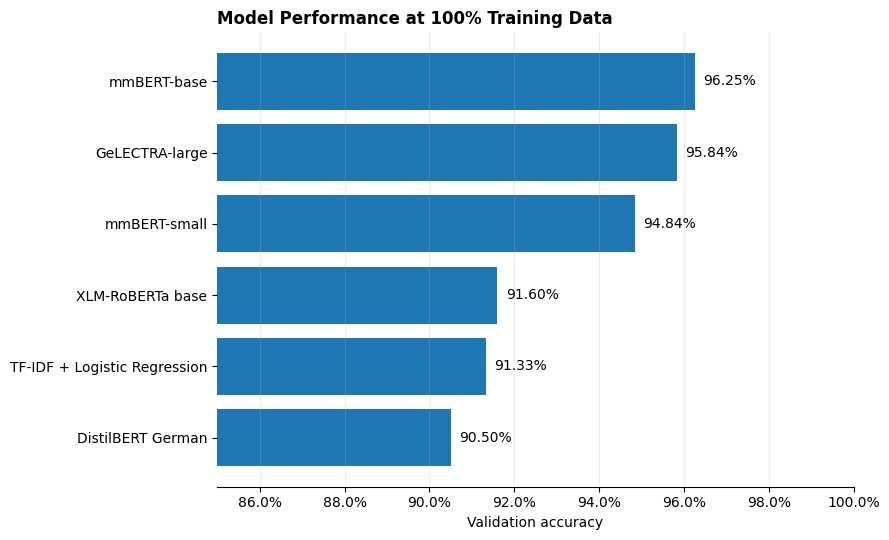

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter


files = {
    "TF-IDF + Logistic Regression":
        "tfidf-logreg-learning-curve.csv",
    "DistilBERT German":
        "distilbert-german-learning-curve.csv",
    "mmBERT-small":
        "mmbert-small-learning-curve.csv",
    "mmBERT-base":
        "mmbert-base-learning-curve.csv",
    "GeLECTRA-large":
        "gelectra-large-learning-curve.csv",
    "XLM-RoBERTa base":
        "xlm-roberta-base-learning-curve.csv",
}


rows = []

for model_name, file_path in files.items():
    df = pd.read_csv(file_path)

    final_row = (
        df.sort_values("training_fraction")
        .iloc[-1]
    )

    rows.append(
        {
            "model": model_name,
            "validation_accuracy":
                final_row["validation_accuracy"],
        }
    )


final_results = (
    pd.DataFrame(rows)
    .sort_values(
        "validation_accuracy",
        ascending=True,
    )
)


fig, ax = plt.subplots(
    figsize=(9, 5.5)
)

bars = ax.barh(
    final_results["model"],
    final_results["validation_accuracy"],
)

ax.set_xlim(
    0.85,
    1.00,
)

ax.xaxis.set_major_formatter(
    PercentFormatter(1.0)
)

ax.set_xlabel(
    "Validation accuracy"
)

ax.set_title(
    "Model Performance at 100% Training Data",
    loc="left",
    fontweight="bold",
)

ax.spines[
    ["top", "right", "left"]
].set_visible(False)

ax.grid(
    axis="x",
    alpha=0.25,
)

for bar, accuracy in zip(
    bars,
    final_results["validation_accuracy"],
):
    ax.text(
        accuracy + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f"{accuracy:.2%}",
        va="center",
        fontsize=10,
    )

fig.tight_layout()

fig.savefig(
    "final-model-comparison.svg",
    bbox_inches="tight",
)

plt.show()

## Data-Efficiency Comparison

Compare validation accuracy at selected training-set sizes to evaluate how efficiently each model benefits from additional training data.

training_data,1%,50%,100%
model,,,
DistilBERT German,46.42%,87.82%,90.50%
GeLECTRA-large,69.34%,93.98%,95.84%
TF-IDF + Logistic Regression,76.29%,90.33%,91.33%
XLM-RoBERTa base,51.72%,88.58%,91.60%
mmBERT-base,65.97%,95.11%,96.25%
mmBERT-small,37.54%,94.53%,94.84%


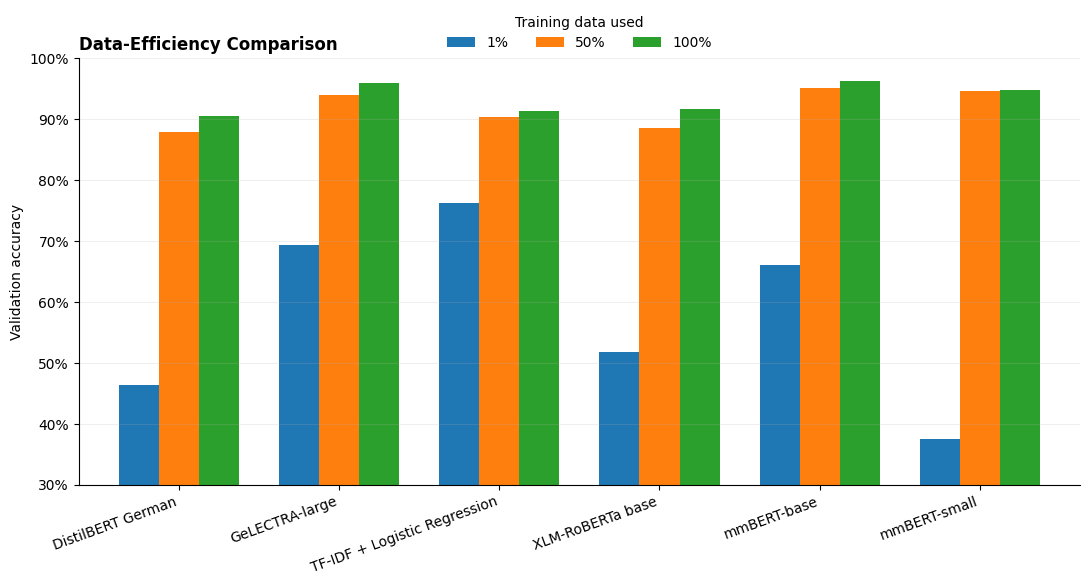

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter


files = {
    "TF-IDF + Logistic Regression":
        "tfidf-logreg-learning-curve.csv",
    "DistilBERT German":
        "distilbert-german-learning-curve.csv",
    "mmBERT-small":
        "mmbert-small-learning-curve.csv",
    "mmBERT-base":
        "mmbert-base-learning-curve.csv",
    "GeLECTRA-large":
        "gelectra-large-learning-curve.csv",
    "XLM-RoBERTa base":
        "xlm-roberta-base-learning-curve.csv",
}


target_fractions = {
    "1%": 0.01,
    "50%": 0.50,
    "100%": 1.00,
}


rows = []

for model_name, file_path in files.items():
    df = pd.read_csv(file_path)

    for label, target in target_fractions.items():
        row = df.iloc[
            np.argmin(
                np.abs(
                    df["training_fraction"]
                    - target
                )
            )
        ]

        rows.append(
            {
                "model": model_name,
                "training_data": label,
                "validation_accuracy":
                    row["validation_accuracy"],
            }
        )


comparison = pd.DataFrame(rows)

comparison["training_data"] = pd.Categorical(
    comparison["training_data"],
    categories=[
        "1%",
        "50%",
        "100%",
    ],
    ordered=True,
)

comparison_table = (
    comparison
    .pivot(
        index="model",
        columns="training_data",
        values="validation_accuracy",
    )
    .reindex(
        columns=[
            "1%",
            "50%",
            "100%",
        ]
    )
)

display(
    comparison_table.style.format(
        "{:.2%}"
    )
)


ax = comparison_table.plot(
    kind="bar",
    figsize=(11, 6),
    width=0.75,
    color=[
        "#1f77b4",
        "#ff7f0e",
        "#2ca02c",
    ],
)

ax.yaxis.set_major_formatter(
    PercentFormatter(1.0)
)

ax.set_ylim(
    0.30,
    1.00,
)

ax.set_xlabel("")

ax.set_ylabel(
    "Validation accuracy"
)

ax.set_title(
    "Data-Efficiency Comparison",
    loc="left",
    fontweight="bold",
)

ax.legend(
    title="Training data used",
    frameon=False,
    ncol=3,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.13),
)

ax.grid(
    axis="y",
    alpha=0.2,
)

ax.spines[
    ["top", "right"]
].set_visible(False)

plt.xticks(
    rotation=20,
    ha="right",
)

fig = ax.get_figure()

fig.tight_layout()

fig.savefig(
    "data-efficiency-comparison-1-50-100.svg",
    bbox_inches="tight",
)

fig.savefig(
    "data-efficiency-comparison-1-50-100.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()